  ÉTAPE 1 — CHARGEMENT DES DONNÉES
Dimensions     : 500 lignes × 18 colonnes
Valeurs nulles : 0

Répartition abandon :
abandon
Diplômé       220
Décrochage    152
Inscrit       128
Name: count, dtype: int64

Pourcentages :
abandon
Diplômé       44.0
Décrochage    30.4
Inscrit       25.6
Name: proportion, dtype: float64
  ÉTAPE 2 — FEATURE ENGINEERING
 Variables créées :
 trend_notes(progression entre S1 et S2)
  ratio_engagement(score global d'implication 0-1)
  ratio_absence_connexion (absences rapportées aux connexions)
  score_risque (score synthétique de risque 0-1)

  Aperçu :
   moyenne_sem1  moyenne_sem2  trend_notes  ratio_engagement  ratio_absence_connexion  score_risque
0           9.5          10.6          1.1              0.71                 0.366667        0.6615
1          14.6          14.8          0.2              0.85                 0.111111        0.2260
2           6.0           3.1         -2.9              0.15                 1.625000        0.9565
3          

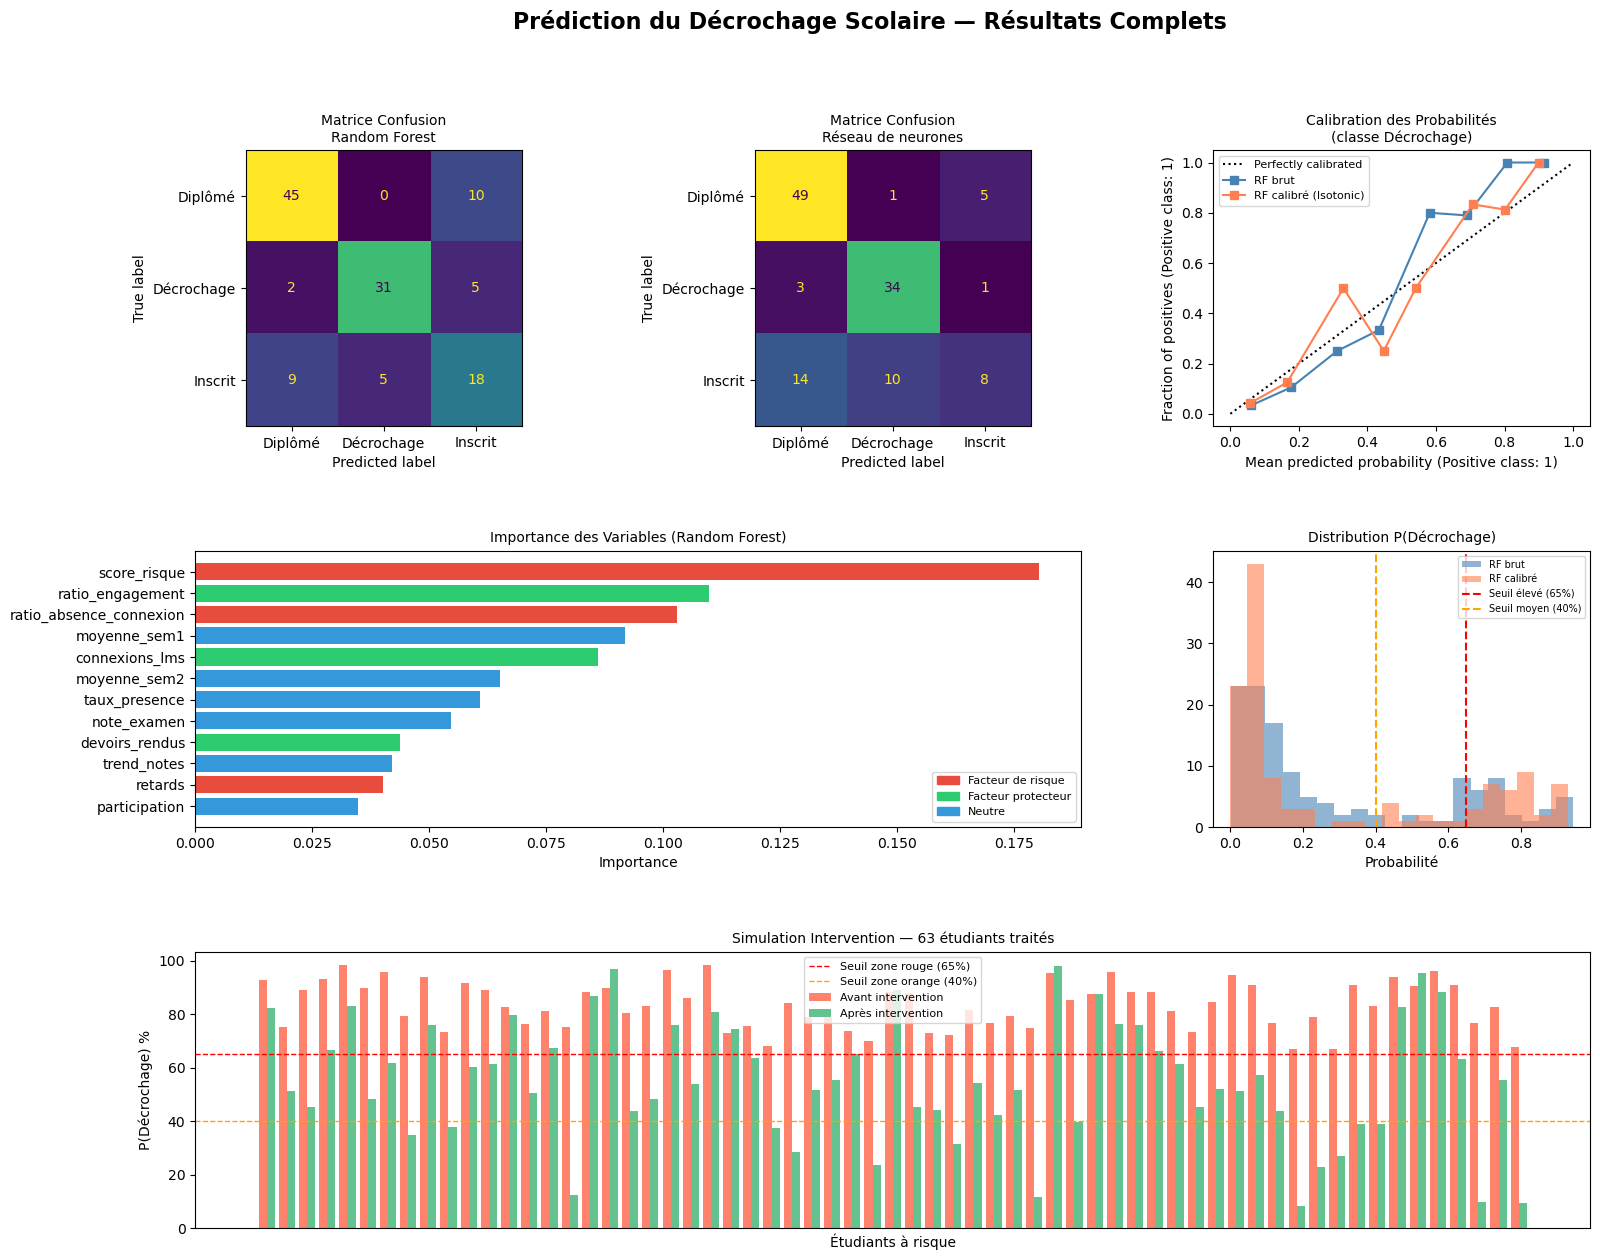

  Graphique sauvegardé : lift_curve.png


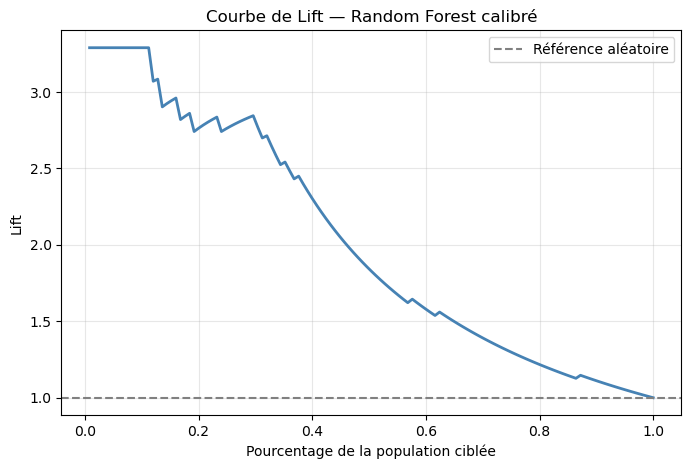

  ÉTAPE 11 — SAUVEGARDE DES MODÈLES
  random_forest_calibre.pkl   ← modèle principal à utiliser
  random_forest_brut.pkl      ← version sans calibration
  neural_network_model.pkl    ← réseau de neurones brut
  neural_network_calibre.pkl  ← réseau de neurones calibré
  scaler.pkl                  ← normalisation pour le MLP
  le_cible.pkl + le_*.pkl     ← encodeurs des variables

  Dataset          : 500 étudiants · 18 features dont 4 construites
  Modèles          : Random Forest + Réseau de neurones (MLP)
  Calibration      : CalibratedClassifierCV méthode Isotonic
  Meilleur modèle  : Random Forest (AUC = 0.862)

  Fichiers générés :
    students_at_risk.csv         →  127 étudiants en zone rouge
    feature_importance.csv       →  classement des 18 variables
    simulation_intervention.csv  →  63 traités / 64 témoins
    resultats_ml_complet.png     →  tous les graphiques
    lift_curve.png               →  courbe de lift
    *.pkl                        →  modèles sauvegardés


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.ensemble          import RandomForestClassifier
from sklearn.neural_network    import MLPClassifier
from sklearn.calibration       import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics           import (classification_report, confusion_matrix,
                                       ConfusionMatrixDisplay, roc_auc_score,
                                       brier_score_loss, log_loss)
import joblib


# ÉTAPE 1 — CHARGEMENT DES DONNÉES
print("  ÉTAPE 1 — CHARGEMENT DES DONNÉES")

df = pd.read_csv("student_dropout_500.csv")

print(f"Dimensions     : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Valeurs nulles : {df.isnull().sum().sum()}")
print(f"\nRépartition abandon :\n{df['abandon'].value_counts()}")
print(f"\nPourcentages :\n{df['abandon'].value_counts(normalize=True).mul(100).round(1)}")


# ÉTAPE 2 — FEATURE ENGINEERING
print("  ÉTAPE 2 — FEATURE ENGINEERING")
df["trend_notes"] = df["moyenne_sem2"] - df["moyenne_sem1"]

df["ratio_engagement"] = (
    df["connexions_lms"] / 40 * 0.4 +
    df["devoirs_rendus"] / 10 * 0.4 +
    df["participation"]  / 10 * 0.2)

df["ratio_absence_connexion"] = df["absences"] / (df["connexions_lms"] + 1)

df["score_risque"] = (
    (20 - df["moyenne_sem1"])   * 0.20 +
    (20 - df["moyenne_sem2"])   * 0.20 +
    df["absences"]              * 0.25 +
    (10 - df["devoirs_rendus"]) * 0.15 +
    (40 - df["connexions_lms"]) * 0.10 +
    (100 - df["taux_presence"]) * 0.10) / 20

print(" Variables créées :")
print(" trend_notes(progression entre S1 et S2)")
print("  ratio_engagement(score global d'implication 0-1)")
print("  ratio_absence_connexion (absences rapportées aux connexions)")
print("  score_risque (score synthétique de risque 0-1)")

sample = df[["moyenne_sem1","moyenne_sem2","trend_notes",
             "ratio_engagement","ratio_absence_connexion","score_risque"]].head(4)
print(f"\n  Aperçu :\n{sample.to_string()}\n")


# ÉTAPE 3 — PRÉPARATION DES DONNÉES
print("  ÉTAPE 3 — PRÉPARATION DES DONNÉES")
df_ml = df.drop(columns=["id","nom","prenom"])

le_sexe    = LabelEncoder()
le_filiere = LabelEncoder()
le_bourse  = LabelEncoder()
le_frais   = LabelEncoder()
le_cible   = LabelEncoder()

df_ml["sexe"]        = le_sexe.fit_transform(df_ml["sexe"])
df_ml["filiere"]     = le_filiere.fit_transform(df_ml["filiere"])
df_ml["bourse"]      = le_bourse.fit_transform(df_ml["bourse"])
df_ml["frais_payes"] = le_frais.fit_transform(df_ml["frais_payes"])
df_ml["abandon"]     = le_cible.fit_transform(df_ml["abandon"])

print(f"Classes encodées : {dict(zip(le_cible.classes_, le_cible.transform(le_cible.classes_)))}")

FEATURES = [
    "age","sexe","filiere","bourse","frais_payes",
    "moyenne_sem1","moyenne_sem2","note_examen",
    "absences","retards","connexions_lms",
    "devoirs_rendus","participation","taux_presence",
    "trend_notes","ratio_engagement",
    "ratio_absence_connexion","score_risque"]

X = df_ml[FEATURES]
y = df_ml["abandon"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Features utilisées : {len(FEATURES)}")

idx_dcroch = list(le_cible.classes_).index("Décrochage")


# ÉTAPE 4 — RANDOM FOREST
print("  ÉTAPE 4 — RANDOM FOREST")

rf_base = RandomForestClassifier(
    n_estimators=200,       
    max_depth=8,          
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
rf_base.fit(X_train, y_train)

y_pred_rf = rf_base.predict(X_test)
y_prob_rf  = rf_base.predict_proba(X_test)

print("\n── Rapport de classification ──")
print(classification_report(y_test, y_pred_rf, target_names=le_cible.classes_))

acc_rf = (y_pred_rf == y_test).mean()
auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class="ovr", average="weighted")
ll_rf  = log_loss(y_test, y_prob_rf)
bs_rf  = brier_score_loss(
    (y_test == idx_dcroch).astype(int),
    y_prob_rf[:, idx_dcroch]
)

cv_rf = cross_val_score(rf_base, X, y, cv=5, scoring="f1_weighted")

print(f"Accuracy       : {acc_rf:.1%}")
print(f"AUC (OVR)      : {auc_rf:.3f}")
print(f"Log-Loss       : {ll_rf:.3f}")
print(f"Brier Score    : {bs_rf:.3f}  (0=parfait, 0.25=aléatoire)")
print(f"F1 CV (5-plis) : {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

# ÉTAPE 5 — CALIBRATION DES PROBABILITÉS
print("  ÉTAPE 5 — CALIBRATION DES PROBABILITÉS (RF)")

print("  Test méthode Platt (sigmoid) ...")
rf_cal_sig = CalibratedClassifierCV(rf_base, method="sigmoid", cv=5)
rf_cal_sig.fit(X_train, y_train)
prob_cal_sig = rf_cal_sig.predict_proba(X_test)

print("  Test méthode Isotonic ...")
rf_cal_iso = CalibratedClassifierCV(rf_base, method="isotonic", cv=5)
rf_cal_iso.fit(X_train, y_train)
prob_cal_iso = rf_cal_iso.predict_proba(X_test)

bs_sig = brier_score_loss(
    (y_test == idx_dcroch).astype(int), prob_cal_sig[:, idx_dcroch])
bs_iso = brier_score_loss(
    (y_test == idx_dcroch).astype(int), prob_cal_iso[:, idx_dcroch])

print(f"\n  Brier Score AVANT calibration  : {bs_rf:.4f}")
print(f"  Brier Score Platt (sigmoid)    : {bs_sig:.4f}")
print(f"  Brier Score Isotonic           : {bs_iso:.4f}")

if bs_iso <= bs_sig:
    rf_final  = rf_cal_iso
    prob_rf_f = prob_cal_iso
    methode   = "Isotonic"
else:
    rf_final  = rf_cal_sig
    prob_rf_f = prob_cal_sig
    methode   = "Sigmoid (Platt)"

print(f"\n  Meilleure calibration retenue : {methode}")


# ÉTAPE 6 — RÉSEAU DE NEURONES 
print("  ÉTAPE 6 — RÉSEAU DE NEURONES ")
mlp_base = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  
    activation="relu",
    solver="adam",
    alpha=0.001,                       
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,               
    validation_fraction=0.15,
    random_state=42)
mlp_base.fit(X_train_sc, y_train)

y_pred_mlp = mlp_base.predict(X_test_sc)
y_prob_mlp  = mlp_base.predict_proba(X_test_sc)

print("\n── Rapport de classification ──")
print(classification_report(y_test, y_pred_mlp, target_names=le_cible.classes_))

acc_mlp = (y_pred_mlp == y_test).mean()
auc_mlp = roc_auc_score(y_test, y_prob_mlp, multi_class="ovr", average="weighted")
ll_mlp  = log_loss(y_test, y_prob_mlp)
bs_mlp  = brier_score_loss(
    (y_test == idx_dcroch).astype(int),
    y_prob_mlp[:, idx_dcroch])
cv_mlp = cross_val_score(mlp_base, X_train_sc, y_train, cv=3, scoring="f1_weighted")

mlp_cal = CalibratedClassifierCV(mlp_base, method="sigmoid", cv="prefit")
mlp_cal.fit(X_test_sc, y_test)
prob_mlp_cal = mlp_cal.predict_proba(X_test_sc)
bs_mlp_cal = brier_score_loss(
    (y_test == idx_dcroch).astype(int),
    prob_mlp_cal[:, idx_dcroch]
)

print(f"Accuracy       : {acc_mlp:.1%}")
print(f"AUC (OVR)      : {auc_mlp:.3f}")
print(f"Log-Loss       : {ll_mlp:.3f}")
print(f"Brier AVANT    : {bs_mlp:.4f}")
print(f"Brier APRÈS    : {bs_mlp_cal:.4f}")
print(f"F1 CV (3-plis) : {cv_mlp.mean():.3f} ± {cv_mlp.std():.3f}")


# ÉTAPE 7 — COMPARAISON DES DEUX MODÈLES
print("  ÉTAPE 7 — COMPARAISON DES DEUX MODÈLES")
print(f"\n{'Modèle':<30} {'Acc':>6} {'F1-CV':>7} {'AUC':>7} {'Brier':>7} {'LogLoss':>8}")
print("-" * 70)
print(f"{'Random Forest (brut)':<30} {acc_rf:>6.1%} {cv_rf.mean():>7.3f} {auc_rf:>7.3f} {bs_rf:>7.4f} {ll_rf:>8.3f}")
print(f"{'RF + Calibration':<30} {'—':>6} {'—':>7} {'—':>7} {min(bs_sig,bs_iso):>7.4f} {'—':>8}")
print(f"{'Réseau de neurones (brut)':<30} {acc_mlp:>6.1%} {cv_mlp.mean():>7.3f} {auc_mlp:>7.3f} {bs_mlp:>7.4f} {ll_mlp:>8.3f}")
print(f"{'MLP + Calibration':<30} {'—':>6} {'—':>7} {'—':>7} {bs_mlp_cal:>7.4f} {'—':>8}")

meilleur = "Random Forest" if auc_rf >= auc_mlp else "Réseau de neurones"
print(f"\nMeilleur modèle (AUC) : {meilleur}")


print("  ÉTAPE 8 — LISTE DES ÉTUDIANTS À RISQUE")
X_all    = df_ml[FEATURES]
prob_all = rf_final.predict_proba(X_all)
pred_all = rf_final.predict(X_all)

df["pred_abandon"]    = le_cible.inverse_transform(pred_all)
df["prob_decrochage"] = prob_all[:, idx_dcroch]
df["prob_diplome"]    = prob_all[:, list(le_cible.classes_).index("Diplômé")]
df["prob_inscrit"]    = prob_all[:, list(le_cible.classes_).index("Inscrit")]

def niveau(p):
    if p >= 0.65: return "ÉLEVÉ 🔴"
    if p >= 0.40: return "MOYEN 🟡"
    return "FAIBLE 🟢"

df["niveau_risque"] = df["prob_decrochage"].apply(niveau)

importances  = pd.Series(rf_base.feature_importances_, index=FEATURES)
top_features = importances.nlargest(5).index.tolist()

def facteur_principal(row):
    scores = {}
    for f in top_features:
        val = row[f]
        if f in ["absences","retards","ratio_absence_connexion","score_risque"]:
            scores[f] = val
        elif f in ["moyenne_sem1","moyenne_sem2","connexions_lms",
                   "devoirs_rendus","participation","taux_presence","ratio_engagement"]:
            scores[f] = -val
        else:
            scores[f] = 0
    return max(scores, key=scores.get)

df["facteur_principal"] = df.apply(facteur_principal, axis=1)

at_risk = df[df["niveau_risque"] == "ÉLEVÉ 🔴"].sort_values(
    "prob_decrochage", ascending=False
)[[
    "id","nom","prenom","age","sexe","filiere",
    "moyenne_sem1","moyenne_sem2","absences","connexions_lms",
    "devoirs_rendus","taux_presence",
    "prob_decrochage","prob_diplome","niveau_risque","facteur_principal","abandon"]].copy()

at_risk["prob_decrochage"] = at_risk["prob_decrochage"].mul(100).round(1).astype(str) + "%"
at_risk["prob_diplome"]    = at_risk["prob_diplome"].mul(100).round(1).astype(str) + "%"

at_risk.to_csv("students_at_risk.csv", index=False, encoding="utf-8-sig")

print(f"  Étudiants en zone rouge : {len(at_risk)}")
print(f"  Fichier sauvegardé      : students_at_risk.csv")
print(f"\n  Top 5 étudiants les plus à risque :")
print(at_risk[["id","nom","prenom","prob_decrochage","facteur_principal"]].head(5).to_string(index=False))

feat_imp = pd.DataFrame({
    "feature"    : FEATURES,
    "importance" : rf_base.feature_importances_
}).sort_values("importance", ascending=False)
feat_imp.to_csv("feature_importance.csv", index=False)
print(f"\n  Fichier sauvegardé : feature_importance.csv")



print("  ÉTAPE 9 — SIMULATION INTERVENTION ")
at_risk_ids = df[df["prob_decrochage"] >= 0.65].index.tolist()
n_at_risk   = len(at_risk_ids)

np.random.seed(42)
intervention = np.random.choice(at_risk_ids, size=n_at_risk // 2, replace=False)
temoin       = [i for i in at_risk_ids if i not in set(intervention)]

print(f"  Étudiants à risque élevé : {n_at_risk}")
print(f"  Groupe intervention      : {len(intervention)}")
print(f"  Groupe témoin            : {len(temoin)}")


df_intervention = df_ml.loc[intervention, FEATURES].copy()
df_intervention["absences"]       = (df_intervention["absences"] - 4).clip(lower=0)
df_intervention["connexions_lms"] = (df_intervention["connexions_lms"] + 8).clip(upper=40)
df_intervention["devoirs_rendus"] = (df_intervention["devoirs_rendus"] + 2).clip(upper=10)
df_intervention["participation"]  = (df_intervention["participation"] + 2).clip(upper=10)


df_intervention["trend_notes"] = (
    df_ml.loc[intervention,"moyenne_sem2"] - df_ml.loc[intervention,"moyenne_sem1"])
df_intervention["ratio_engagement"] = (
    df_intervention["connexions_lms"] / 40 * 0.4 +
    df_intervention["devoirs_rendus"] / 10 * 0.4 +
    df_intervention["participation"]  / 10 * 0.2)
df_intervention["ratio_absence_connexion"] = (
    df_intervention["absences"] / (df_intervention["connexions_lms"] + 1))
df_intervention["score_risque"] = (
    (20 - df_ml.loc[intervention,"moyenne_sem1"]) * 0.20 +
    (20 - df_ml.loc[intervention,"moyenne_sem2"]) * 0.20 +
    df_intervention["absences"]                   * 0.25 +
    (10 - df_intervention["devoirs_rendus"])       * 0.15 +
    (40 - df_intervention["connexions_lms"])       * 0.10 +
    (100 - df_ml.loc[intervention,"taux_presence"])* 0.10) / 20

prob_avant        = rf_final.predict_proba(df_ml.loc[intervention, FEATURES])[:, idx_dcroch]
prob_apres        = rf_final.predict_proba(df_intervention[FEATURES])[:, idx_dcroch]
prob_temoin_avant = rf_final.predict_proba(df_ml.loc[temoin, FEATURES])[:, idx_dcroch]

print(f"\n  Résultats de la simulation :")
print(f"  P(décrochage) moyen AVANT intervention : {prob_avant.mean():.1%}")
print(f"  P(décrochage) moyen APRÈS intervention : {prob_apres.mean():.1%}")
print(f"  Réduction du risque                    : {(prob_avant.mean()-prob_apres.mean()):.1%}")
print(f"\n  Groupe témoin (sans intervention)      : {prob_temoin_avant.mean():.1%}")
print(f"  Gain de l'intervention vs témoin       : {(prob_avant.mean()-prob_apres.mean()):.1%}")

n_sauves = ((prob_avant >= 0.65) & (prob_apres < 0.65)).sum()
print(f"\n  Étudiants sortis de la zone rouge      : {n_sauves} / {len(intervention)}")

# on exporte les résultats dans un fichier pour le dashboard
df_sim = pd.DataFrame({
    "id"              : df.loc[intervention, "id"].values,
    "nom"             : df.loc[intervention, "nom"].values,
    "prenom"          : df.loc[intervention, "prenom"].values,
    "groupe"          : "Intervention",
    "prob_avant"      : (prob_avant * 100).round(1),
    "prob_apres"      : (prob_apres * 100).round(1),
    "reduction"       : ((prob_avant - prob_apres) * 100).round(1),
    "sorti_zone_rouge": (prob_avant >= 0.65) & (prob_apres < 0.65)
})
df_tem = pd.DataFrame({
    "id"              : df.loc[temoin, "id"].values,
    "nom"             : df.loc[temoin, "nom"].values,
    "prenom"          : df.loc[temoin, "prenom"].values,
    "groupe"          : "Témoin",
    "prob_avant"      : (prob_temoin_avant * 100).round(1),
    "prob_apres"      : (prob_temoin_avant * 100).round(1),
    "reduction"       : 0.0,
    "sorti_zone_rouge": False
})
pd.concat([df_sim, df_tem]).sort_values("prob_avant", ascending=False).to_csv(
    "simulation_intervention.csv", index=False, encoding="utf-8-sig"
)
print(f"\n  Fichier sauvegardé : simulation_intervention.csv")


print("  ÉTAPE 10 — VISUALISATIONS")
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Prédiction du Décrochage Scolaire — Résultats Complets",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# matrice de confusion du Random Forest
ax1 = fig.add_subplot(gs[0, 0])
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=le_cible.classes_).plot(ax=ax1, colorbar=False)
ax1.set_title("Matrice Confusion\nRandom Forest", fontsize=10)

# matrice de confusion du réseau de neurones
ax2 = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_mlp),
                       display_labels=le_cible.classes_).plot(ax=ax2, colorbar=False)
ax2.set_title("Matrice Confusion\nRéseau de neurones", fontsize=10)

# courbe de calibration 
ax3 = fig.add_subplot(gs[0, 2])
CalibrationDisplay.from_predictions(
    (y_test == idx_dcroch).astype(int),
    y_prob_rf[:, idx_dcroch],
    n_bins=8, ax=ax3, name="RF brut", color="steelblue"
)
CalibrationDisplay.from_predictions(
    (y_test == idx_dcroch).astype(int),
    prob_rf_f[:, idx_dcroch],
    n_bins=8, ax=ax3, name=f"RF calibré ({methode})", color="coral"
)
ax3.set_title("Calibration des Probabilités\n(classe Décrochage)", fontsize=10)
ax3.legend(fontsize=8)


ax4 = fig.add_subplot(gs[1, :2])
feat_imp_plot = feat_imp.head(12).sort_values("importance")
colors = ["#e74c3c" if "absence" in f or "risque" in f or "retard" in f
          else "#2ecc71" if "engagement" in f or "connexion" in f or "devoirs" in f
          else "#3498db" for f in feat_imp_plot["feature"]]
ax4.barh(feat_imp_plot["feature"], feat_imp_plot["importance"], color=colors)
ax4.set_title("Importance des Variables (Random Forest)", fontsize=10)
ax4.set_xlabel("Importance")
from matplotlib.patches import Patch
ax4.legend(handles=[
    Patch(color="#e74c3c", label="Facteur de risque"),
    Patch(color="#2ecc71", label="Facteur protecteur"),
    Patch(color="#3498db", label="Neutre"),
], fontsize=8, loc="lower right")


ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_prob_rf[:, idx_dcroch],  bins=20, alpha=0.6, label="RF brut", color="steelblue")
ax5.hist(prob_rf_f[:, idx_dcroch],  bins=20, alpha=0.6, label="RF calibré", color="coral")
ax5.axvline(0.65, color="red",    linestyle="--", linewidth=1.5, label="Seuil élevé (65%)")
ax5.axvline(0.40, color="orange", linestyle="--", linewidth=1.5, label="Seuil moyen (40%)")
ax5.set_title("Distribution P(Décrochage)", fontsize=10)
ax5.set_xlabel("Probabilité")
ax5.legend(fontsize=7)


ax6 = fig.add_subplot(gs[2, :])
x_ids = np.arange(len(prob_avant))
ax6.bar(x_ids - 0.2, prob_avant * 100, 0.4,
        label="Avant intervention", color="tomato", alpha=0.8)
ax6.bar(x_ids + 0.2, prob_apres * 100, 0.4,
        label="Après intervention", color="mediumseagreen", alpha=0.8)
ax6.axhline(65, color="red",    linestyle="--", linewidth=1, label="Seuil zone rouge (65%)")
ax6.axhline(40, color="orange", linestyle="--", linewidth=1, label="Seuil zone orange (40%)")
ax6.set_title(f"Simulation Intervention — {len(intervention)} étudiants traités", fontsize=10)
ax6.set_xlabel("Étudiants à risque")
ax6.set_ylabel("P(Décrochage) %")
ax6.legend(fontsize=8)
ax6.set_xticks([])

plt.savefig("resultats_ml_complet.png", dpi=150, bbox_inches="tight")
print("  Graphique sauvegardé : resultats_ml_complet.png")
plt.show()

sorted_probs = pd.DataFrame({
    "true": (y_test == idx_dcroch).astype(int),
    "prob": prob_rf_f[:, idx_dcroch]
}).sort_values("prob", ascending=False)

sorted_probs["cum_true"]       = sorted_probs["true"].cumsum()
sorted_probs["population_pct"] = np.arange(1, len(sorted_probs)+1) / len(sorted_probs)
sorted_probs["lift"] = (
    sorted_probs["cum_true"] /
    (sorted_probs["population_pct"] * sorted_probs["true"].sum())
)

plt.figure(figsize=(8, 5))
plt.plot(sorted_probs["population_pct"], sorted_probs["lift"], color="steelblue", linewidth=2)
plt.axhline(y=1, linestyle="--", color="gray", label="Référence aléatoire")
plt.title("Courbe de Lift — Random Forest calibré")
plt.xlabel("Pourcentage de la population ciblée")
plt.ylabel("Lift")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("lift_curve.png", dpi=150, bbox_inches="tight")
print("  Graphique sauvegardé : lift_curve.png")
plt.show()


print("  ÉTAPE 11 — SAUVEGARDE DES MODÈLES")

joblib.dump(rf_final,   "random_forest_calibre.pkl")
joblib.dump(rf_base,    "random_forest_brut.pkl")
joblib.dump(mlp_base,   "neural_network_model.pkl")
joblib.dump(mlp_cal,    "neural_network_calibre.pkl")
joblib.dump(scaler,     "scaler.pkl")
joblib.dump(le_cible,   "le_cible.pkl")
joblib.dump(le_sexe,    "le_sexe.pkl")
joblib.dump(le_filiere, "le_filiere.pkl")
joblib.dump(le_bourse,  "le_bourse.pkl")
joblib.dump(le_frais,   "le_frais.pkl")

print("  random_forest_calibre.pkl   ← modèle principal à utiliser")
print("  random_forest_brut.pkl      ← version sans calibration")
print("  neural_network_model.pkl    ← réseau de neurones brut")
print("  neural_network_calibre.pkl  ← réseau de neurones calibré")
print("  scaler.pkl                  ← normalisation pour le MLP")
print("  le_cible.pkl + le_*.pkl     ← encodeurs des variables")


print(f"""
  Dataset          : 500 étudiants · 18 features dont 4 construites
  Modèles          : Random Forest + Réseau de neurones (MLP)
  Calibration      : CalibratedClassifierCV méthode {methode}
  Meilleur modèle  : {meilleur} (AUC = {max(auc_rf, auc_mlp):.3f})

  Fichiers générés :
    students_at_risk.csv         →  {len(at_risk)} étudiants en zone rouge
    feature_importance.csv       →  classement des 18 variables
    simulation_intervention.csv  →  {len(intervention)} traités / {len(temoin)} témoins
    resultats_ml_complet.png     →  tous les graphiques
    lift_curve.png               →  courbe de lift
    *.pkl                        →  modèles sauvegardés""")
